# Соберем сверточную нейронную сеть LiNet5

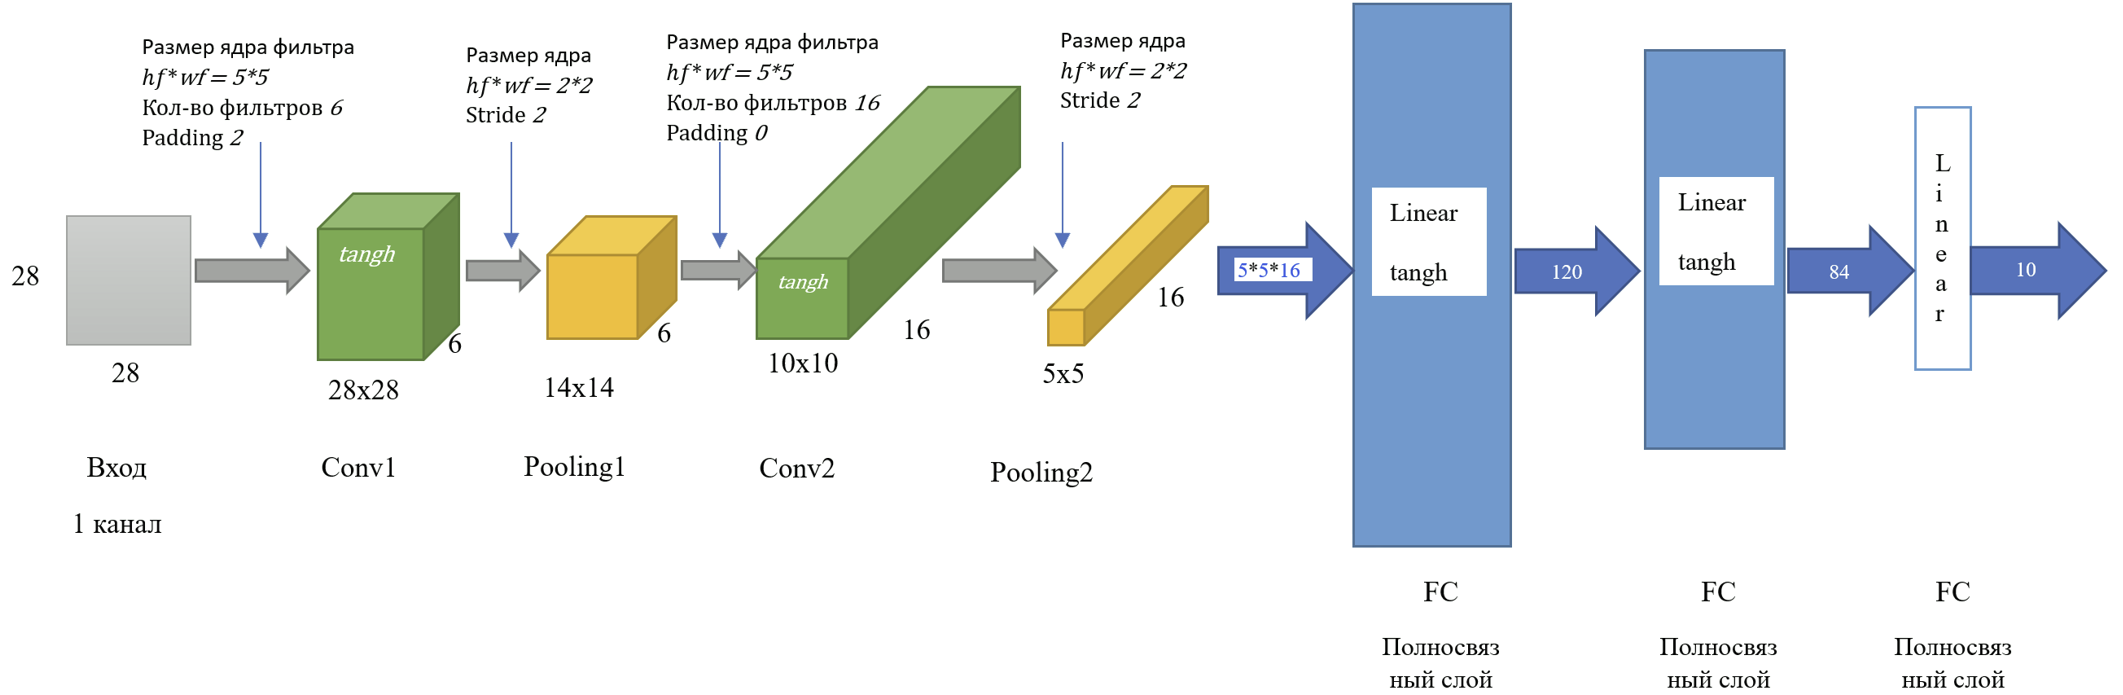


В архитектуре нейронной сети, показанной выше:

**Слой Conv1** представляет собой сверточный слой с шестью картами признаков, размер которых составляет $28 \times 28$, функция активации $tangh$;

**Слой Pooling1** – это слой подвыборки (polling) с шестью картами признаков, размер которых составляет $14 \times 14$, функция активации $AvgPooling$;

**Слой Conv2** представляет собой сверточный слой с шестнадцатью характеристическими картами (слоями), размер которых составляет $10 \times 10$, функция активации $tangh$;

**Слой Pooling2** является слоем подвыборки с шестнадцатью характеристическими картами, размер которых составляет $5 \times 5$, функция активации $AvgPooling$;

**Слой FC** представляет собой полносвязанный слой, вход $5 \times 5 \times 16$ нейронов (признаков), выход $120$ нейронов, функция активации $tangh$;

**Слой FC** представляет собой полносвязанный слой, вход $120$ нейронов (признаков), выход $84$ нейрона, функция активации $tangh$;

**Слой FC** представляет собой полносвязанный слой, вход $84$ нейронов (признаков), выход $10$ нейронов;



In [ ]:
# импортируем библиотеки

import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [ ]:
# это для cuda .
#torch.cuda.memory_summary(device=None, abbreviated=True)

In [ ]:
# это для cuda. принудительно освобождение памяти, что иногда, но очень редко, помогает решить проблему с отказом
# cuda использовать память
#import gc
#gc.collect()

#torch.cuda.empty_cache()

In [ ]:
# будем использовать встроенные датасеты торча.
# полный список - тут https://pytorch.org/vision/stable/datasets.html


import torchvision.datasets

In [ ]:
# загружаем сразу в трайн и тест
MNIST_train = torchvision.datasets.MNIST('./', download=True, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=True, train=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.40MB/s]


In [ ]:
# формируем датасеты для обучения, тестирования, целевые переменные
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

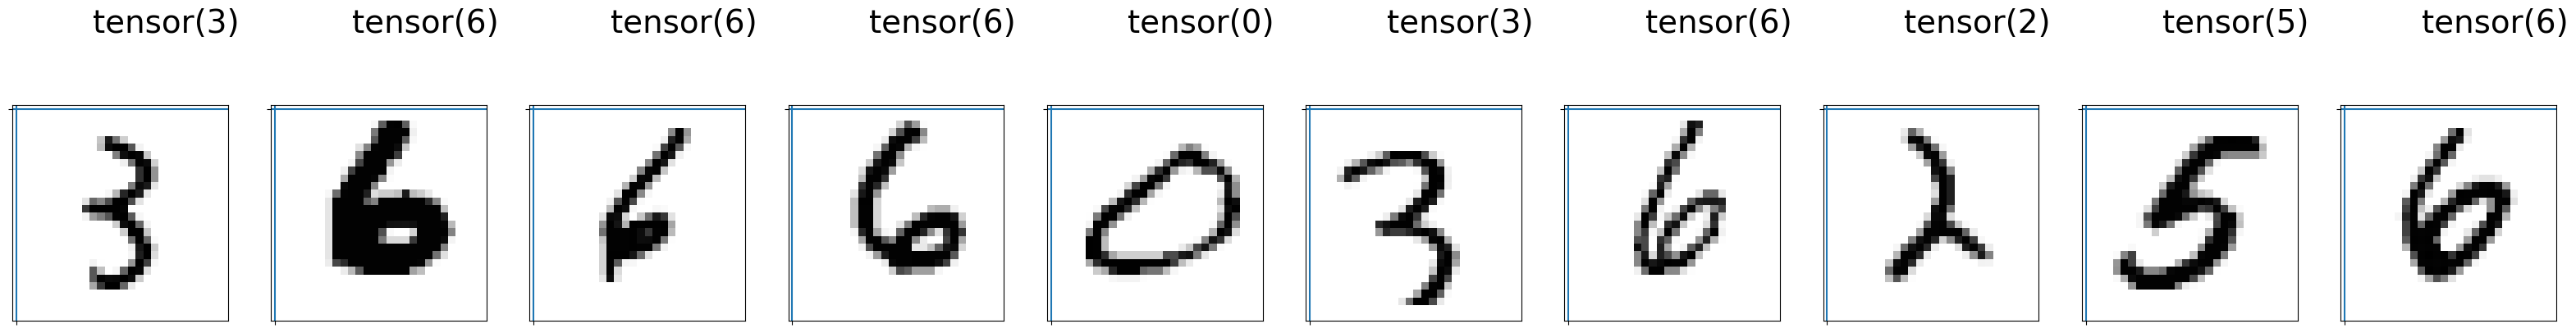

In [ ]:
# посмотрим, что пришло

import numpy as np
import matplotlib.pyplot as plt

# посмотрим какие-то произвольные изображения из датасета
count = 0
sample_size = 10  # сколько картинок будем смотреть
plt.figure(figsize=(40, 20))
for i in np.random.permutation(X_train.shape[0])[:sample_size]:
    count = count + 1
    plt.subplot(1, sample_size, count)
    plt.axhline('')
    plt.axvline('')
    plt.text(x=10, y=-10, s=y_train[i], fontsize=28)
    plt.imshow(X_train[i].reshape(28, 28), cmap=plt.cm.Greys)
plt.show()

In [ ]:
# сколько изображений в трейне и тесте
len(y_train), len(y_test)

(60000, 10000)

image:
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219,
         166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254,
         254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0, 

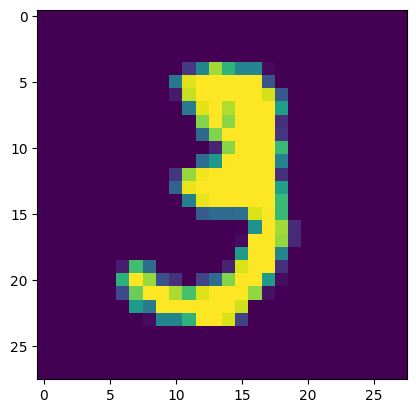

tensor(3)


In [ ]:
# нарисуем, c чем мы имеем дело
import matplotlib.pyplot as plt

im_number = 10

# вот как хранятся изображения в компьютере
print(f"image:\n{X_train[im_number, :, :]}")

# а так их видим мы
plt.imshow(X_train[im_number, :, :])

plt.show()
print(y_train[im_number])

In [ ]:
# посмотртим тип "картинок"
type(X_train[10, :, :])

torch.Tensor

In [ ]:
X_train.shape

torch.Size([60000, 28, 28])

In [ ]:
# unsqueeze - Возвращает новый тензор с увеличенной на 1 размерностью, которая вставляется в указанную позицию.
# было torch.Size([60000, 28, 28])  ---- станет torch.Size([60000, 1, 28, 28])
# и все значения - во float

X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [ ]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [ ]:
X_test.shape

torch.Size([10000, 1, 28, 28])

In [ ]:
# Определяем класс, которые и будет представлять нашу нейронку
# какие слои - см описание вначале блокнота

class LeNet5(torch.nn.Module):
    # конструктор. Определям вообще какие слои у нас будут
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10)

    # наша самая главная функция. Определяем, что и в каком порядке будет вызываться
    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

# переменная - наша нейронка
lenet5 = LeNet5()

In [ ]:
# определяем, где будет обучаться наша СNN
# если есть граф процессор от Nvidia, то на нем. Если нет, то на cpu

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device = "cpu"

# отправляем туда нашу нейронку
lenet5 = lenet5.to(device)

# ЕСЛИ ВЫ ОБУЧИТЕ НЕЙРОНКУ НА GPU или CPU ОНА ДЛЯ СВОЕЙ РАБОТЫ БУДЕТ ТРЕБОВАТЬ ИЛИ GPU, ИЛИ CPU
Поэтому не всегда возможно использование обучения на GPU просто потому, что сервер или компьютер пользователя не будет поддерживать расчеты на GPU

In [ ]:
# в качестве функции потерь будем использовать CrossEntropyLoss()
loss = torch.nn.CrossEntropyLoss()

# в качестве оптимайзера, который будет вычислять градиенты и минимизировать функцию потерь, будем использовать Adam (Адаптивная оценка момента)
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [ ]:
# будем оптимизировать по 100 параметров одним комплектом (бачем)
batch_size = 100

# чтобы посмотреть, как и что у нас тут менялось при оптимизации на тестовой выборке
test_accuracy_history = []
test_loss_history = []


train_loss_history = []

# не забываем отправить все выборки на устройство, на котором обучаем
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(100):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        # обязательно обнуляем градиенты
        optimizer.zero_grad()

        # берем пачку параметров
        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        # делаем предсказание
        preds = lenet5.forward(X_batch)

        # считаем лосс значение
        loss_value = loss(preds, y_batch)

        # берем градиенты
        loss_value.backward()

        # и пусть оптимайзер все оптимизирует
        optimizer.step()

    # смотрим, что он тут нам напредсказывал, не забывая вовремя отправлять на cpu
    train_loss_history.append(loss_value.data.cpu())

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())


    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(f"epoch{epoch} - accuracy test {accuracy} ")

TypeError: only integer scalar arrays can be converted to a scalar index

<ipython-input-18-fd538a322c0e>:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


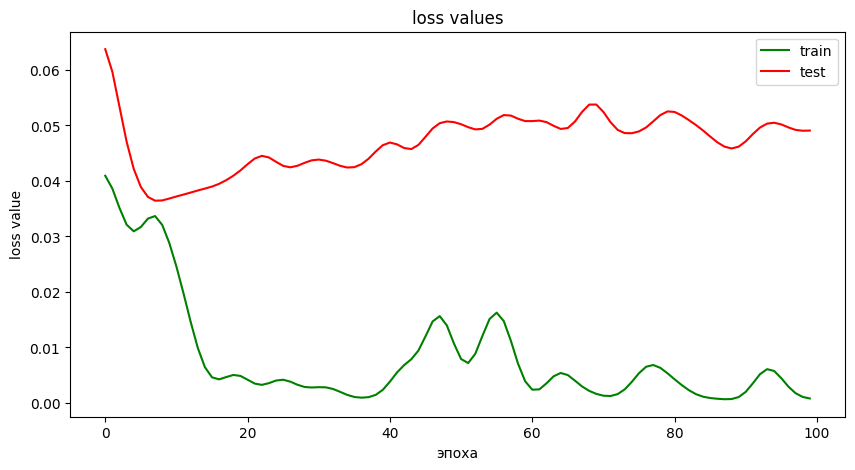

In [ ]:
# строим графики - функции потерь

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'loss value')
train_loss_smoothed = gaussian_filter1d(train_loss_history, sigma=2)
ax.plot(train_loss_smoothed, color='green',  label='train')

test_loss_smoothed = gaussian_filter1d(test_loss_history, sigma=2)
ax.plot(test_loss_smoothed, color='red',  label='test')
ax.legend()
plt.show()



<ipython-input-19-7ea75e20b699>:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


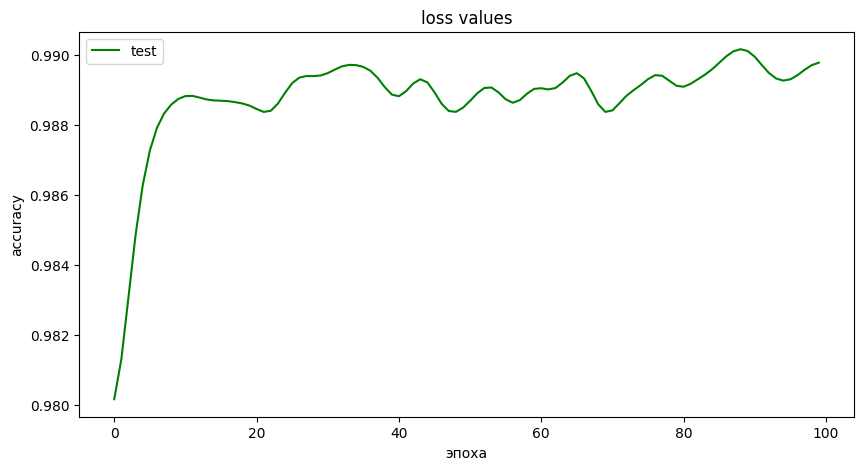

In [ ]:
# График изменения accuracy на тестовых данных

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'accuracy')
test_accuracy_smoothed = gaussian_filter1d(test_accuracy_history, sigma=2)
ax.plot(test_accuracy_smoothed, color='green',  label='test')

ax.legend()
plt.show()


# Сохранение и использование модели

In [ ]:
# сохраняем произвольное число из датасета (тензор) в файл
timg = X_train[0]

torch.save(timg,'tensor.pt')


In [ ]:
# смотрим размер тензора - изображения
timg.size()

torch.Size([1, 28, 28])

In [ ]:
# и размер того, что изначально скармливали нейронке.
# тензор подобного размера надо будет скормить нейронке для предсказания

X_test.size()

# то есть нам нужен тензор размера [1,1,28,28]

torch.Size([10000, 1, 28, 28])

In [ ]:
!pip install dill

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 4.5 MB/s eta 0:00:00


In [ ]:
# вот так сохраняют модель с помощью dill
import dill

with open("model.dill", "wb") as dill_file:
    dill.dump(lenet5, dill_file)


In [ ]:
# вот так сохраняют модель с помощью pickle
import pickle

with open("model.pickle", "wb") as pickle_file:
    pickle.dump(lenet5, pickle_file)



In [ ]:
# считываем модель, сохраненную в dill

ifile = open("model.dill", "rb")
modelp = dill.load(ifile)
ifile.close()

# загружаем наше изображение
test_data = torch.load('tensor.pt')

# смотрим, что пришло из dill файла
print(modelp)


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act1): Tanh()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (act3): Tanh()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
# смотрим тип модели
type(modelp)

__main__.LeNet5

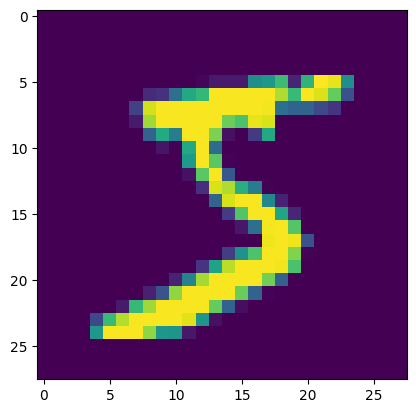

In [ ]:
# смотрим, что за цифру считали
plt.imshow(test_data[0, :, :])
plt.show()

In [ ]:
# переводим входной тензор-изображение в тензор нужного нам размера
t_data = torch.tensor([test_data.numpy()])

<ipython-input-29-94f1da74720b>:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  t_data = torch.tensor([test_data.numpy()])


In [ ]:
# проверяем
t_data.shape

torch.Size([1, 1, 28, 28])

In [ ]:
# проверяем, на чем можем считать
dev = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# отправляем туда модель
modelp.to(dev)
model_data = modelp.to(dev)

# тензор-изображение тоже
t_data = t_data.to(dev)

In [ ]:
# делаем предсказание
preds = modelp.forward(t_data)

In [ ]:
# в каком виде получаем предсказание. Это вектор 10x1 с вероятностями принадлежности объекта к определенному классу
print(preds)

tensor([[ -3.4298,  -5.6792, -11.1934,  11.1278,  -5.4120,  22.6160,  -4.9824,
          -3.1714,   1.3048,  -4.2625]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [ ]:
# выбираем максимальную вероятность, как результат предсказания.
# Не забывая отправить на cpu
prediction = np.argmax(preds.to('cpu').detach().numpy(),axis=1)

In [ ]:
# смотрим, что предсказалось
print(prediction)

0


Цифра предсказана верно.

**Упражнение. Выберите случайным образом изображение из тестового набора и сделайте предсказание для него.**

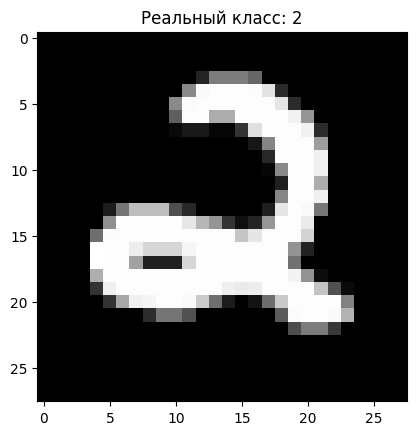

Реальный класс: 2, Предсказанный класс: 2


In [ ]:
# ваш код здесь
import random

# Выбираем случайное изображение из тестового набора
random_index = random.randint(0, len(X_test) - 1)
sample_image = X_test[random_index].unsqueeze(0).to(device)  # Добавляем batch-дименсию
sample_label = y_test[random_index].item()

# Отображаем изображение
plt.imshow(sample_image.cpu().squeeze(), cmap="gray")
plt.title(f"Реальный класс: {sample_label}")
plt.show()

# Выполняем предсказание
with torch.no_grad():
    prediction = lenet5(sample_image)

predicted_label = torch.argmax(prediction).item()
print(f"Реальный класс: {sample_label}, Предсказанный класс: {predicted_label}")

***Задание. Реализовать классификацию изображений на своем датасете.***

1. Выберите датасет для классификации изображений https://pytorch.org/vision/stable/datasets.html
2. Определите архитектуру нейросети и приведите ее описание (текстом или иным способом) в своей работе
3. Реализуйте выбранную архитектуру в виде класса
4. Обучите нейросеть
5. Постройте на одном графике кривые изменения функции потерь на тесте и обучении
6. Постройте график изменения выбранной метрики качества на тесте
7. Сохраните в файл одно изображение из тестовой выборки
8. Сохраните обученную нейросеть в файл
9. Загрузите изображение из файла
10. Загрузите нейросеть
11. Выполните предсказание с помощью загруженной из файла нейросети и оцените его правильность

In [1]:
# импортируем библиотеки

import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [2]:
# будем использовать встроенные датасеты торча.
# полный список - тут https://pytorch.org/vision/stable/datasets.html


import torchvision.datasets

In [3]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


DTD_train = datasets.DTD('./', split='train', download=True, transform=transform)
DTD_test = datasets.DTD('./', split='test', download=True, transform=transform)

classes = DTD_train.classes


100%|██████████| 625M/625M [00:32<00:00, 19.1MB/s]


In [4]:
classes

['banded',
 'blotchy',
 'braided',
 'bubbly',
 'bumpy',
 'chequered',
 'cobwebbed',
 'cracked',
 'crosshatched',
 'crystalline',
 'dotted',
 'fibrous',
 'flecked',
 'freckled',
 'frilly',
 'gauzy',
 'grid',
 'grooved',
 'honeycombed',
 'interlaced',
 'knitted',
 'lacelike',
 'lined',
 'marbled',
 'matted',
 'meshed',
 'paisley',
 'perforated',
 'pitted',
 'pleated',
 'polka-dotted',
 'porous',
 'potholed',
 'scaly',
 'smeared',
 'spiralled',
 'sprinkled',
 'stained',
 'stratified',
 'striped',
 'studded',
 'swirly',
 'veined',
 'waffled',
 'woven',
 'wrinkled',
 'zigzagged']

In [5]:

X_train = [item[0] for item in DTD_train]
y_train = [item[1] for item in DTD_train]

X_test = [item[0] for item in DTD_test]
y_test = [item[1] for item in DTD_test]


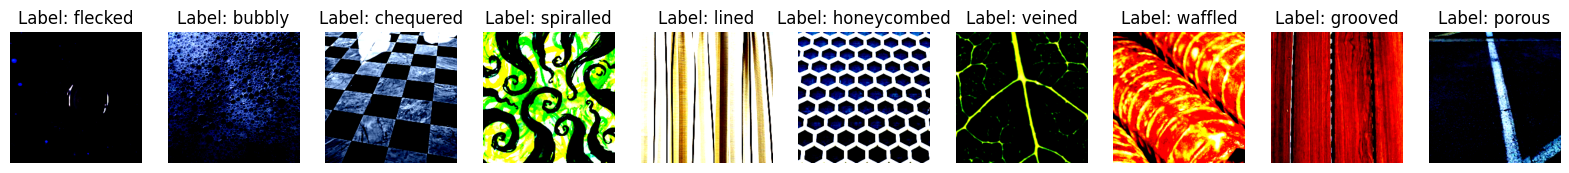

In [6]:
import numpy as np
import matplotlib.pyplot as plt


count = 0
sample_size = 10
plt.figure(figsize=(20, 10))


random_indices = np.random.permutation(len(X_train))[:sample_size]

for i in random_indices:
    count += 1
    plt.subplot(1, sample_size, count)
    plt.axis('off')
    plt.title(f"Label: {classes[y_train[i]]}")
    plt.imshow(X_train[i].permute(1, 2, 0))

plt.show()


In [7]:
# сколько изображений в трейне и тесте
len(y_train), len(y_test)

(1880, 1880)

Image data:
tensor([[[ 1.8379,  1.8037,  1.9749,  ...,  2.2489,  2.2489,  2.2489],
         [ 1.8037,  1.8379,  1.9578,  ...,  2.2489,  2.2489,  2.2489],
         [ 1.7694,  1.7865,  1.7865,  ...,  2.2489,  2.2489,  2.2489],
         ...,
         [ 2.2489,  2.2489,  2.2489,  ...,  1.8550,  1.8379,  1.7865],
         [ 2.2489,  2.2489,  2.2489,  ...,  1.8893,  1.8722,  1.7865],
         [ 2.2489,  2.2489,  2.2489,  ...,  1.8037,  1.8037,  1.7865]],

        [[-1.7031, -1.8081, -0.1975,  ...,  2.4286,  2.4286,  2.4286],
         [-2.0007, -1.5105, -0.3200,  ...,  2.4286,  2.4286,  2.4286],
         [-2.0357, -2.0182, -2.0182,  ...,  2.4286,  2.4286,  2.4286],
         ...,
         [ 2.4286,  2.4286,  2.4286,  ..., -1.4405, -1.4405, -2.0182],
         [ 2.4286,  2.4286,  2.4111,  ..., -1.2129, -1.2129, -2.0182],
         [ 2.4286,  2.4286,  2.4286,  ..., -1.9307, -1.9307, -2.0182]],

        [[-1.1944, -1.2990,  0.1999,  ...,  2.6400,  2.6400,  2.6400],
         [-1.4733, -1.0201,  0.11

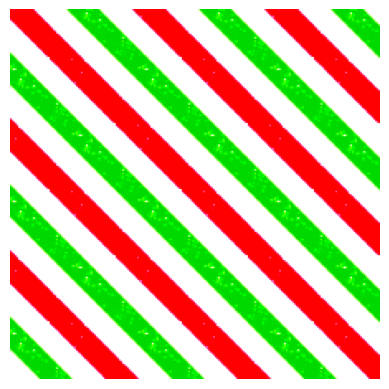

Label: banded


In [8]:
import matplotlib.pyplot as plt

im_number = 10

print(f"Image data:\n{X_train[im_number]}")

plt.imshow(X_train[im_number].permute(1, 2, 0))
plt.axis('off')
plt.show()

print(f"Label: {classes[y_train[im_number]]}")

In [9]:
# посмотрим тип "картинок"
image_type = type(X_train[im_number])
image_shape = X_train[im_number].shape

print(f"Type of image data: {image_type}")
print(f"Shape of image data: {image_shape}")


Type of image data: <class 'torch.Tensor'>
Shape of image data: torch.Size([3, 224, 224])


In [10]:
if isinstance(X_train, list):
    first_image_shape = X_train[0].shape
    print(f"Shape of the first image: {first_image_shape}")
else:
    print(f"Shape of X_train: {X_train.shape}")

Shape of the first image: torch.Size([3, 224, 224])


In [11]:
if isinstance(X_train, list):
    first_image_shape = X_test[0].shape
    print(f"Shape of the first image: {first_image_shape}")
else:
    print(f"Shape of X_train: {X_test.shape}")

Shape of the first image: torch.Size([3, 224, 224])


In [12]:
import torch
import torch.nn as nn
import keras

import tensorflow as tf


class LeNet5Modified(nn.Module):
    def __init__(self, num_classes=47):  # DTD has 47 classes
        super(LeNet5Modified, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2)
        self.act1 = nn.LeakyReLU(0.1)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5, padding=2)
        self.act2 = nn.LeakyReLU(0.1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=12, out_channels=18, kernel_size=5, padding=2)
        self.act3 = nn.LeakyReLU(0.1)
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(in_channels=18, out_channels=24, kernel_size=5, padding=2)
        self.act4 = nn.LeakyReLU(0.1)
        self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv5 = nn.Conv2d(in_channels=24, out_channels=30, kernel_size=5, padding=2)
        self.act5 = nn.LeakyReLU(0.1)
        self.pool5 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Calculate the correct input size for the fully connected layer
        # Assuming input images are 224x224
        self.fc1 = nn.Linear(30 * 7 * 7, 120)  # Adjust this size based on your input dimensions
        self.act6 = nn.LeakyReLU(0.1)

        self.fc2 = nn.Linear(120, 84)
        self.act7 = nn.LeakyReLU(0.1)

        self.fc3 = nn.Linear(84, num_classes)  # Adjust the output size to the number of DTD classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.pool3(x)

        x = self.conv4(x)
        x = self.act4(x)
        x = self.pool4(x)

        x = self.conv5(x)
        x = self.act5(x)
        x = self.pool5(x)

        x = x.view(x.size(0), -1)  # Flatten the tensor

        x = self.fc1(x)
        x = self.act6(x)
        x = self.fc2(x)
        x = self.act7(x)
        x = self.fc3(x)

        return x
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Instantiate the neural network
lenet5 = LeNet5Modified().to(device)



Входной слой:

Сеть ожидает, что входные изображения будут иметь 3 цветовых канала (RGB) и пространственный размер 224x224 пикселя.

Сверточные слои:

1. Conv1: Сверточный слой с 6 фильтрами, каждый размером 5x5, нанесенными с отступом 2 для сохранения пространственных размеров. За ним следует функция активации LeakyReLU с наклоном 0,1 и средний слой объединения с размером ядра 2x2 и шагом 2.
2. Conv2: Сверточный слой с 12 фильтрами, каждый размером 5x5, нанесенный с отступом 2. За ним следует функция активации LeakyReLU с наклоном 0,1 и средний слой объединения с размером ядра 2x2 и шагом 2.
3. Conv3: Сверточный слой с 18 фильтрами, каждый размером 5x5, нанесенный с отступом 2. За ним следует функция активации LeakyReLU с наклоном 0,1 и средний слой объединения с размером ядра 2x2 и шагом 2.
4. Conv4: Сверточный слой с 24 фильтрами, каждый размером 5x5, нанесенный с отступом 2. За ней следует функция активации LeakyReLU с наклоном 0,1 и средний слой объединения с размером ядра 2x2 и шагом 2.
5. Conv5: Сверточный слой с 30 фильтрами, каждый размером 5x5, нанесенный с отступом 2. За ним следует функция активации LeakyReLU с наклоном 0,1 и средний объединяющий слой с размером ядра 2x2 и шагом 2.

Полносвязные слои:

1. FC1: Полностью подключенный слой, который принимает сглаженный выходной сигнал от последнего сверточного слоя и преобразует его в 120 единиц. За ним следует функция активации LeakyReLU с наклоном 0,1.
2. FC2: Полностью подключенный слой, который сопоставляет 120 объектов с 84 объектами. За ним следует функция активации LeakyReLU с наклоном 0,1.
3. FC3: Последний полностью связанный слой, который сопоставляет 84 объекта с числом выходных классов, которое равно 47 для набора данных описываемых текстур (DTD).

Выходной слой:

Выходной слой создает вектор размером 47, представляющий оценки для каждого из 47 классов в наборе данных DTD.


In [13]:
# определяем, где будет обучаться наша СNN
# если есть граф процессор от Nvidia, то на нем. Если нет, то на cpu

#device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device = "cpu"

# отправляем туда нашу нейронку
lenet5 = lenet5.to(device)

# ЕСЛИ ВЫ ОБУЧИТЕ НЕЙРОНКУ НА GPU или CPU ОНА ДЛЯ СВОЕЙ РАБОТЫ БУДЕТ ТРЕБОВАТЬ ИЛИ GPU, ИЛИ CPU
Поэтому не всегда возможно использование обучения на GPU просто потому, что сервер или компьютер пользователя не будет поддерживать расчеты на GPU

In [14]:
# в качестве функции потерь будем использовать CrossEntropyLoss()
loss = torch.nn.CrossEntropyLoss()

# в качестве оптимайзера, который будет вычислять градиенты и минимизировать функцию потерь, будем использовать Adam (Адаптивная оценка момента)
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [15]:
import numpy as np
import torch


batch_size = 100


test_accuracy_history = []
test_loss_history = []
train_loss_history = []


y_test = torch.tensor(y_test).clone().detach().to(device)
y_train = torch.tensor(y_train).clone().detach().to(device)
X_test = torch.stack([torch.tensor(img).clone().detach() for img in X_test]).to(device)

for epoch in range(100):

    order = np.random.permutation(len(X_train))


    for start_index in range(0, len(X_train), batch_size):

        optimizer.zero_grad()


        batch_indexes = order[start_index:start_index + batch_size]


        X_batch = torch.stack([X_train[i] for i in batch_indexes]).to(device)
        y_batch = torch.tensor([y_train[i] for i in batch_indexes], device=device)


        preds = lenet5(X_batch)


        loss_value = loss(preds, y_batch)


        loss_value.backward()


        optimizer.step()


    train_loss_history.append(loss_value.detach().cpu().item())


    lenet5.eval()
    with torch.no_grad():
        test_preds = lenet5(X_test)
        test_loss_value = loss(test_preds, y_test)
        test_loss_history.append(test_loss_value.detach().cpu().item())


        accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().cpu().item()
        test_accuracy_history.append(accuracy)

    lenet5.train()

    print(f"Epoch {epoch} - Test Accuracy: {accuracy:.4f}")


<ipython-input-15-8a0aa4728911>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.stack([torch.tensor(img).clone().detach() for img in X_test]).to(device)


Epoch 0 - Test Accuracy: 0.0351
Epoch 1 - Test Accuracy: 0.0452
Epoch 2 - Test Accuracy: 0.0527
Epoch 3 - Test Accuracy: 0.0596
Epoch 4 - Test Accuracy: 0.0553
Epoch 5 - Test Accuracy: 0.0638
Epoch 6 - Test Accuracy: 0.0702
Epoch 7 - Test Accuracy: 0.0718
Epoch 8 - Test Accuracy: 0.0718
Epoch 9 - Test Accuracy: 0.0697
Epoch 10 - Test Accuracy: 0.0835
Epoch 11 - Test Accuracy: 0.0862
Epoch 12 - Test Accuracy: 0.0920
Epoch 13 - Test Accuracy: 0.0793
Epoch 14 - Test Accuracy: 0.0926
Epoch 15 - Test Accuracy: 0.0856
Epoch 16 - Test Accuracy: 0.0952
Epoch 17 - Test Accuracy: 0.0862
Epoch 18 - Test Accuracy: 0.0904
Epoch 19 - Test Accuracy: 0.0963
Epoch 20 - Test Accuracy: 0.0840
Epoch 21 - Test Accuracy: 0.0750
Epoch 22 - Test Accuracy: 0.0941
Epoch 23 - Test Accuracy: 0.0824
Epoch 24 - Test Accuracy: 0.0910
Epoch 25 - Test Accuracy: 0.0782
Epoch 26 - Test Accuracy: 0.0771
Epoch 27 - Test Accuracy: 0.0846
Epoch 28 - Test Accuracy: 0.0878
Epoch 29 - Test Accuracy: 0.0883
Epoch 30 - Test Accu

<ipython-input-25-fd538a322c0e>:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


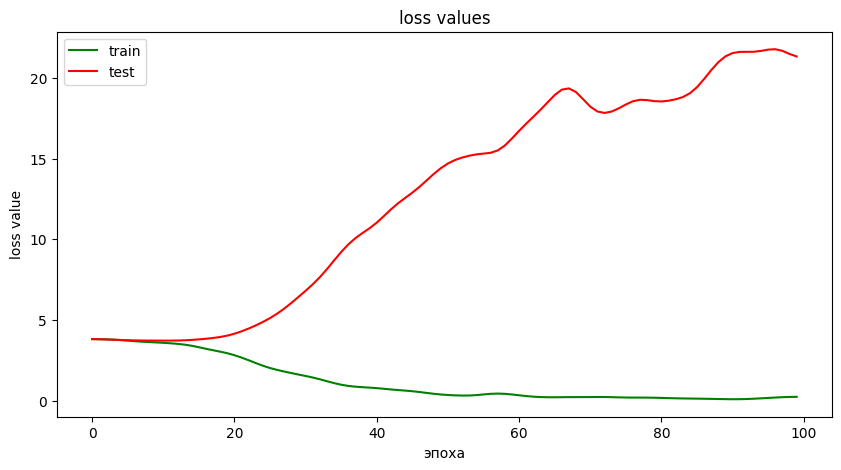

In [25]:
# строим графики - функции потерь

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'loss value')
train_loss_smoothed = gaussian_filter1d(train_loss_history, sigma=2)
ax.plot(train_loss_smoothed, color='green',  label='train')

test_loss_smoothed = gaussian_filter1d(test_loss_history, sigma=2)
ax.plot(test_loss_smoothed, color='red',  label='test')
ax.legend()
plt.show()



<ipython-input-26-7ea75e20b699>:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


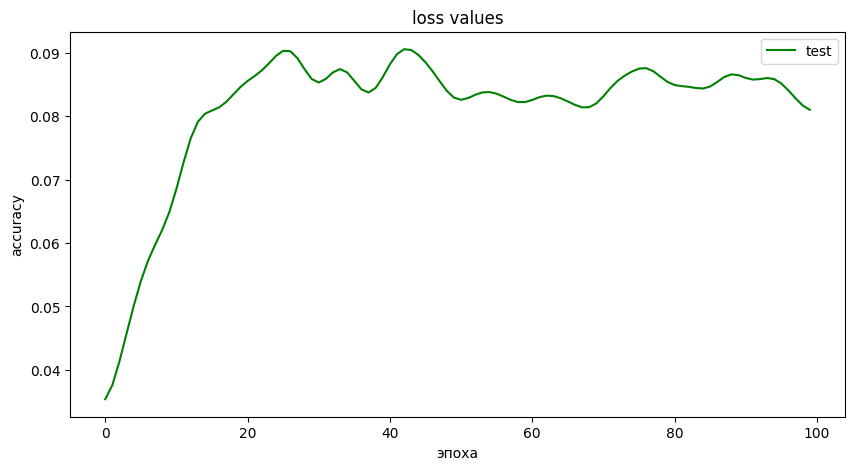

In [26]:
# График изменения accuracy на тестовых данных

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'accuracy')
test_accuracy_smoothed = gaussian_filter1d(test_accuracy_history, sigma=2)
ax.plot(test_accuracy_smoothed, color='green',  label='test')

ax.legend()
plt.show()


# Сохранение и использование модели

In [27]:
# сохраняем произвольное число из датасета (тензор) в файл
timg = X_train[0]

torch.save(timg,'tensor.pt')


In [28]:
# смотрим размер тензора - изображения
timg.size()

torch.Size([3, 224, 224])

In [29]:
# и размер того, что изначально скармливали нейронке.
# тензор подобного размера надо будет скормить нейронке для предсказания

X_test.size()

# то есть нам нужен тензор размера [1,1,28,28]

torch.Size([1880, 3, 224, 224])

In [30]:
!pip install dill

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 2.5 MB/s eta 0:00:00


In [31]:
# вот так сохраняют модель с помощью dill
import dill

with open("model.dill", "wb") as dill_file:
    dill.dump(lenet5, dill_file)


In [32]:
# вот так сохраняют модель с помощью pickle
import pickle

with open("model.pickle", "wb") as pickle_file:
    pickle.dump(lenet5, pickle_file)



In [33]:
# считываем модель, сохраненную в dill

ifile = open("model.dill", "rb")
modelp = dill.load(ifile)
ifile.close()

# загружаем наше изображение
test_data = torch.load('tensor.pt')

# смотрим, что пришло из dill файла
print(modelp)


LeNet5Modified(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act1): LeakyReLU(negative_slope=0.1)
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act2): LeakyReLU(negative_slope=0.1)
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(12, 18, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act3): LeakyReLU(negative_slope=0.1)
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv4): Conv2d(18, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act4): LeakyReLU(negative_slope=0.1)
  (pool4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv5): Conv2d(24, 30, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act5): LeakyReLU(negative_slope=0.1)
  (pool5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=1470, out_features=120, bias=True)
  (act6): LeakyReLU(negative_slope=0.1)
  (fc2): Linea

In [34]:
# смотрим тип модели
type(modelp)

__main__.LeNet5Modified

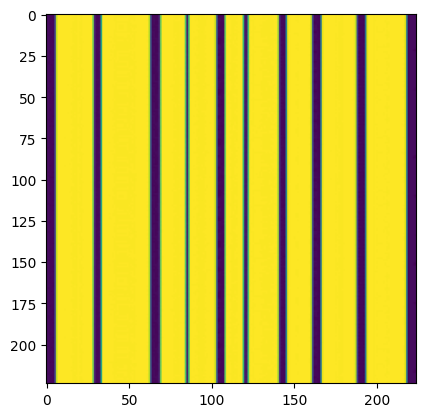

In [35]:
# смотрим, что за текстуру считали
plt.imshow(test_data[0, :, :])
plt.show()

In [36]:
# переводим входной тензор-изображение в тензор нужного нам размера
t_data = torch.tensor([test_data.numpy()])

<ipython-input-36-94f1da74720b>:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  t_data = torch.tensor([test_data.numpy()])


In [37]:
# проверяем
t_data.shape

torch.Size([1, 3, 224, 224])

In [38]:
# проверяем, на чем можем считать
dev = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# отправляем туда модель
modelp.to(dev)
model_data = modelp.to(dev)

# тензор-изображение тоже
t_data = t_data.to(dev)

In [39]:
# делаем предсказание
preds = modelp.forward(t_data)

In [40]:
# в каком виде получаем предсказание. Это вектор 10x1 с вероятностями принадлежности объекта к определенному классу
print(preds)

tensor([[ 29.7721, -14.2913,  14.4187,   1.1006,   3.1336,  -4.0733, -14.2633,
         -25.5322,  -7.9265,   3.9657,   5.6811,  -8.8699,  -8.6606, -25.7191,
          16.5484, -23.1038,  -7.1484,   2.1636,  12.6725,  -0.4778,  12.6214,
         -17.2354,  19.2403, -27.2146, -27.6436,  -4.4812,   5.3302,   0.6429,
         -22.6612, -15.8749,   2.5363, -25.6603, -48.3892, -11.1848,   0.6619,
          10.3383,  18.7934, -28.8996, -10.6578,   6.7102, -17.4838,  21.3138,
           1.3377, -20.6804,  -0.8026,   0.7367,  11.6489]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [41]:
# выбираем максимальную вероятность, как результат предсказания.
# Не забывая отправить на cpu
prediction = np.argmax(preds.to('cpu').detach().numpy(),axis=1)

In [42]:
# смотрим, что предсказалось
print(classes[y_train[prediction]])


banded


Текстура предсказана верно.